In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocessing data

In [2]:
# Get feature name
featurenamefile = 'dataset/Feature_name.dat'
with open(featurenamefile) as file:
    feature_name = [line.rstrip() for line in file]
file.close()
ft_dict = {key: i for i, key in enumerate(feature_name)}
n_feature = len(feature_name)

In [3]:
# read all dataset
# df_normal
# df_coapdos
# df_mqttflood
# df_mqttslowdos
# df_pingflood
# df_portscan
# df_sqlmap
# df_tcpsyn
# df_coapdos = pd.read_csv('./dataset/coap_dos/coap_dos_10x1MB_NAS_Traffic_21_Apr_2024_06_58.csv',header=None, names=feature_name)
# df_mqttflood = pd.read_csv('./dataset/mqttPUBflood/mqttpub_flood_100x10MB_NAS_Traffic_21_Apr_2024_03_39.csv',header=None, names=feature_name)
# df_mqttslowdos = pd.read_csv('./dataset/mqttslowdos/mqtt_slowdos_2k_NAS_Traffic_21_Apr_2024_04_52.csv',header=None, names=feature_name)
# df_pingflood = pd.read_csv('./dataset/pingflood/ping_flood_NAS_Traffic_17_Apr_2024_18_42.csv',header=None, names=feature_name)
# df_portscan = pd.read_csv('./dataset/port_scan/portscan_NAS_Traffic_17_Apr_2024_16_50.csv',header=None, names=feature_name)
# df_sqlmap = pd.read_csv('./dataset/sqlmap/sqlmap_NAS_Traffic_17_Apr_2024_16_07.csv',header=None, names=feature_name)
# df_tcpsyn = pd.read_csv('./dataset/tcpflood/tcp_syn_NAS_Traffic_18_Apr_2024_14_47.csv',header=None, names=feature_name)
# df_normal = pd.read_csv('./dataset/normal/normal_NAS_Traffic_20_Apr_2024_16_00.csv',header=None, names=feature_name)
df_coapdos = pd.read_csv('./dataset/coap_dos/coap_dos_eval_NAS_Traffic_21_Apr_2024_16_24.csv',header=None, names=feature_name)
df_mqttflood = pd.read_csv('./dataset/mqttPUBflood/mqttpub_flood_100x100MB_NAS_Traffic_18_Apr_2024_15_42.csv',header=None, names=feature_name)
df_mqttslowdos = pd.read_csv('./dataset/mqttslowdos/mqtt_slowdos_1k_eval_NAS_Traffic_21_Apr_2024_04_45.csv',header=None, names=feature_name)
df_pingflood = pd.read_csv('./dataset/pingflood/pingflood_spoofed_eval_NAS_Traffic_21_Apr_2024_02_50.csv',header=None, names=feature_name)
df_portscan = pd.read_csv('./dataset/port_scan/portscan_10k_eval_NAS_Traffic_20_Apr_2024_21_57.csv',header=None, names=feature_name)
df_sqlmap = pd.read_csv('./dataset/sqlmap/sqlmap_eval_NAS_Traffic_20_Apr_2024_21_13.csv',header=None, names=feature_name)
df_tcpsyn = pd.read_csv('./dataset/tcpflood/tcpsyn_rand_src_eval_NAS_Traffic_20_Apr_2024_22_05.csv',header=None, names=feature_name)
df_normal = pd.read_csv('./dataset/normal/normal_eval_NAS_Traffic_21_Apr_2024_05_01.csv',header=None, names=feature_name)
df_normal['label'] = 0
df_coapdos['label'] = 1
df_mqttflood['label'] = 2
df_mqttslowdos['label'] = 3
df_pingflood['label'] = 4
df_portscan['label'] = 5
df_sqlmap['label'] = 6
df_tcpsyn['label'] = 7


In [4]:
# Drop columns
drop_columns = ['idx','level','session_id','ue_id','direction']
df_normal.drop(columns=drop_columns,inplace=True)
df_coapdos.drop(columns=drop_columns,inplace=True)
df_mqttflood.drop(columns=drop_columns,inplace=True)
df_mqttslowdos.drop(columns=drop_columns,inplace=True)
df_pingflood.drop(columns=drop_columns,inplace=True)
df_portscan.drop(columns=drop_columns,inplace=True)
df_sqlmap.drop(columns=drop_columns,inplace=True)
df_tcpsyn.drop(columns=drop_columns,inplace=True)

In [5]:
# zero time stamp
def zerotime(df):
    min_timestamp = df['timestamp'].min()
    df['timestamp']= df['timestamp'].apply(lambda x: x-min_timestamp)

def scale(df,ratio):
    df['timestamp']= df['timestamp'].apply(lambda x: x/ratio)

zerotime(df_normal)
zerotime(df_coapdos)
zerotime(df_mqttflood)
zerotime(df_mqttslowdos)
zerotime(df_pingflood)
zerotime(df_portscan)
scale(df_portscan,10)
zerotime(df_sqlmap)
zerotime(df_tcpsyn)

In [6]:
# random new time stamp
def random_starttime(maindf:pd.DataFrame, smalldfs: (pd.DataFrame), min_starttime=None, max_starttime=None):
    '''
    merge small dataset in the big dataset intertwain in random start time manner
    maindf : |--------------------------------------|
    smalldf:        |--------|     |----------|
    '''
    total_attack_time = 0
    for df in smalldfs:
        total_attack_time += df['timestamp'].max()
    print(total_attack_time/60000)

    total_time = maindf['timestamp'].iloc[-1]
    print(total_time/60000)

    n_split = len(smalldfs)
    chunk_time = total_time//n_split

    for i in range(0,len(smalldfs)):
        chunk_start_time = chunk_time*i
        attack_time = smalldfs[i]['timestamp'].iloc[-1]
        print(attack_time/60000)
        spare_time = chunk_time - attack_time
        if spare_time > 0:
            attack_start_time = chunk_start_time + np.random.randint(spare_time)
        else:
            attack_start_time = chunk_start_time

        smalldfs[i]['timestamp'] = smalldfs[i]['timestamp'].apply(lambda x: x + attack_start_time)
        
    df_chunks = [maindf]+smalldfs
    merged_df = pd.concat(df_chunks,ignore_index=True)
    merged_df.sort_values('timestamp',inplace=True)
    merged_df.reset_index(drop=True,inplace=True)
    
    return merged_df
    

smalldfs = [df_coapdos, df_mqttflood, df_mqttslowdos, df_pingflood, df_portscan, df_sqlmap, df_tcpsyn]
merged_df = random_starttime(df_normal, smalldfs)
merged_df['packet_hex'] = merged_df['packet_hex'].map(lambda x: x[2:])



16.75316833333333
70.18978333333334
3.3022
2.454083333333333
0.5641666666666667
0.83575
0.16746833333333333
1.0926666666666667
8.336833333333333


<Axes: >

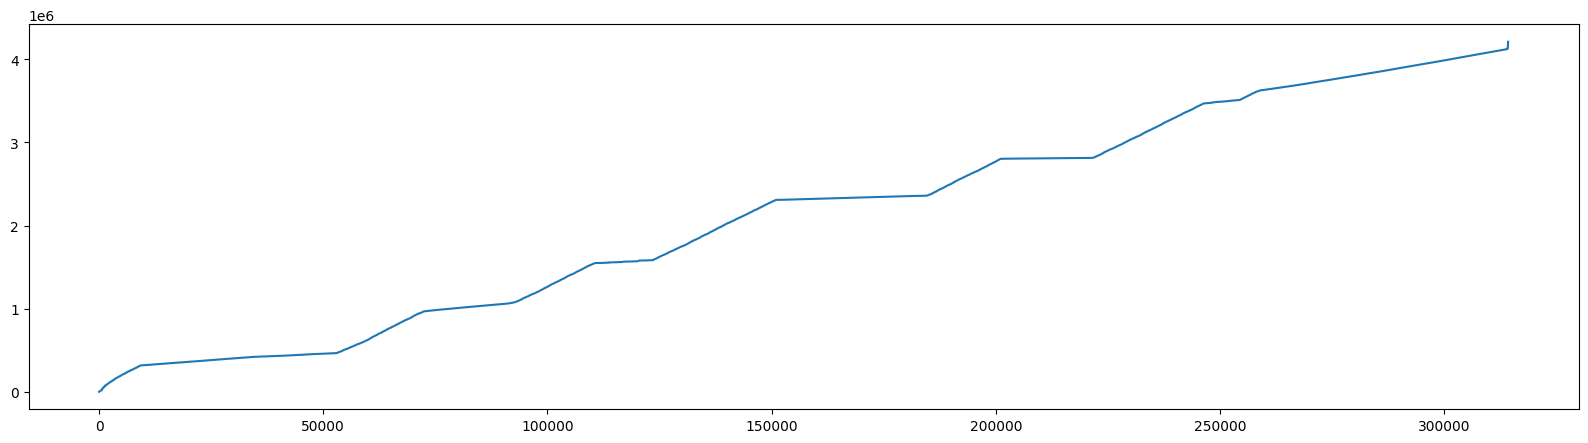

In [7]:
merged_df['timestamp'].plot(figsize=(20,5))


In [8]:
merged_df.to_csv('merged_eval_dataset_by_time.csv',index=False)

In [9]:
# show stat
def showstat(df):
    print('size row,col:',len(df.index),len(df.columns))
        
    colnames = list(df.columns)
    # print('########### column names: ###########\n',colnames)

    print('\n########### column types: ###########\n',colnames)
    print(df.dtypes)

    print('########### Values count: ###########')
    for i in range(len(colnames)):
        print(i,' ',colnames[i],' : ')
        vc = df[colnames[i]].value_counts()
        vc = vc.reindex(sorted(vc.keys()))
        print(vc)

    # print('########### column describe: ###########')
    # for i in range(len(colnames)):
    #     print(df[colnames[i]].describe())
    #     print()

    print('max_time:',df['timestamp'].max()/60000)

print('\ndf_normal')
showstat(df_normal)
print('\ndf_coapdos')
showstat(df_coapdos)
print('\ndf_mqttflood')
showstat(df_mqttflood)
print('\ndf_mqttslowdos')
showstat(df_mqttslowdos)
print('\ndf_pingflood')
showstat(df_pingflood)
print('\ndf_portscan')
showstat(df_portscan)
print('\ndf_sqlmap')
showstat(df_sqlmap)
print('\ndf_tcpsyn')
showstat(df_tcpsyn)


df_normal
size row,col: 140778 3

########### column types: ###########
 ['timestamp', 'packet_hex', 'label']
timestamp      int64
packet_hex    object
label          int64
dtype: object
########### Values count: ###########
0   timestamp  : 
timestamp
0          1
1          1
40         1
50         1
51         2
          ..
4203422    1
4207350    1
4207352    1
4211385    1
4211387    1
Name: count, Length: 92720, dtype: int64
1   packet_hex  : 
packet_hex
0x45000021000c40003f11b74fc0a80116c0a8020a1633ea5d000d300561841348d6                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [10]:
total_sample = 0
for df in smalldfs:
    total_sample+= df.shape[0]
total_sample+=df_normal.shape[0]
print(total_sample)
merged_df

314238


,timestamp,packet_hex,label
0,0.0,4500003c07af40004006ae94c0a80212c0a80116a0ef07...,0
1,1.0,4500003c000040003f06b743c0a80116c0a80212075ba0...,0
2,40.0,4500003407b040004006ae9bc0a80212c0a80116a0ef07...,0
3,50.0,4500004207b140004006ae8cc0a80212c0a80116a0ef07...,0
4,51.0,45000034b92b40003f06fe1fc0a80116c0a80212075ba0...,0
...,...,...,...
314233,4203422.0,450000517bce40003f113b51c0a80116c0a802161633d7...,0
314234,4207350.0,4500006df56840004011c0aec0a80202c0a80116afaa16...,0
314235,4207352.0,450000387c9e40003f113aaec0a80116c0a802021633af...,0
314236,4211385.0,45000039afdb400040110664c0a8020ec0a801168e7516...,0
